#中階三

In [19]:
import pandas as pd
import numpy as np
import random as rnd
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import preprocessing
from random import sample
import matplotlib.colors as pltc
import numpy as np
import pandas as pd
from pandas_profiling import ProfileReport
%matplotlib inline
plt.rcParams['figure.figsize']=(15,8)
from sklearn import tree #導入決策樹模組

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import statsmodels.api as sm 

#匯入文件與查看檔案

In [1]:
import pandas as pd
data=pd.read_excel('nba2.xlsx')

In [17]:
data.head()

,DATASET,R/P,DATE,TEAMS,H/R,W/E,W/L,DIFF,1Q,2Q,3Q,4Q,F,MIN,FG,FGA,3P,3PA,FT,FTA,OR,ORR,DRR,FT%,TOV%,EFG%,DRB%,ORB%,DR,TOT,A,PF,ST,TO,BL,PTS,POSS,PACE,OEFF,DEFF,REST DAYS,OPENING ODDS,SPREAD
0,2016-2017 Regular Season,1,10/25/2016,New York,2,1,0,-29,18,27,19,24,88,240,32,87,9,27,15,20,13,11,40,0.172414,0.158172,0.419540,0.725000,0.245283,29,42,17,22,6,18,6,88,100.4,100.4,87.7,116.6,3,205.5,9.5
1,2016-2017 Regular Season,1,10/25/2016,Cleveland,1,1,1,29,28,20,34,35,117,240,45,94,13,35,14,19,11,13,29,0.148936,0.120316,0.547872,0.754717,0.275000,40,51,31,22,12,14,5,117,100.4,100.4,116.6,87.7,3,-9.5,-9.5
2,2016-2017 Regular Season,1,10/25/2016,Utah,2,2,0,-9,26,20,37,21,104,240,40,82,8,24,16,16,6,5,29,0.195122,0.109956,0.536585,0.833333,0.171429,25,31,19,19,9,11,5,104,92.5,92.5,112.4,122.1,3,194.0,6.0
3,2016-2017 Regular Season,1,10/25/2016,Portland,1,2,1,9,26,28,23,36,113,240,39,75,13,19,22,22,5,6,25,0.293333,0.124121,0.606667,0.828571,0.166667,29,34,22,18,5,12,3,113,92.5,92.5,122.1,112.4,3,-6.0,-6.0
4,2016-2017 Regular Season,1,10/25/2016,San Antonio,2,2,1,29,31,33,33,32,129,240,47,98,12,24,23,26,21,8,27,0.234694,0.106174,0.540816,0.809524,0.437500,34,55,25,19,13,13,3,129,98.8,98.8,130.6,101.2,3,210.5,8.0


In [11]:
data[["TOT","DR","OR","H/R","W/E","1Q","2Q","3Q","3P","A","ST","TO"]].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2460 entries, 0 to 2459
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   TOT     2460 non-null   int64
 1   DR      2460 non-null   int64
 2   OR      2460 non-null   int64
 3   H/R     2460 non-null   int64
 4   W/E     2460 non-null   int64
 5   1Q      2460 non-null   int64
 6   2Q      2460 non-null   int64
 7   3Q      2460 non-null   int64
 8   3P      2460 non-null   int64
 9   A       2460 non-null   int64
 10  ST      2460 non-null   int64
 11  TO      2460 non-null   int64
dtypes: int64(12)
memory usage: 249.8 KB


In [ ]:
data.info()

In [13]:
data[["TOT","DR","OR","H/R","W/E","1Q","2Q","3Q","3P","A","ST","TO"]].head()

,TOT,DR,OR,H/R,W/E,1Q,2Q,3Q,3P,A,ST,TO
0,42,29,13,2,1,18,27,19,9,17,6,18
1,51,40,11,1,1,28,20,34,13,31,12,14
2,31,25,6,2,2,26,20,37,8,19,9,11
3,34,29,5,1,2,26,28,23,13,22,5,12
4,55,34,21,2,2,31,33,33,12,25,13,13


#使用變異數分析

In [48]:
one=["TOT","DR","OR","1Q","2Q","3Q","3P","A","ST","TO"]
name2=[]
alist2=[]
pvlist2=[]
for i in range(len(one)):
  (a2,pv2)=stats.f_oneway(data[one[i]][data['W/L']==0],
                          data[one[i]][data['W/L']==1])
  name2.append(one[i])
  alist2.append(a2)
  pvlist2.append(pv2)

result2=pd.DataFrame(alist2,name2,columns=['F_value'])
result2.insert(1,'p-value',pvlist2)
result2['是否顯著'] = result2["p-value"].apply(lambda x:"顯著影響" if x<=0.05 else 0)#新增一行表示變數是否有顯著影響
result2

,F_value,p-value,是否顯著
TOT,178.698113,2.140753e-39,顯著影響
DR,330.869590,1.828317e-69,顯著影響
OR,4.348504,3.714440e-02,顯著影響
1Q,156.986161,5.887485e-35,顯著影響
2Q,155.138091,1.411436e-34,顯著影響
3Q,185.237739,1.002774e-40,顯著影響
3P,196.725606,4.726052e-43,顯著影響
A,271.757649,5.427676e-58,顯著影響
ST,50.604077,1.476007e-12,顯著影響
TO,32.063278,1.665941e-08,顯著影響


從上圖可看出"TOT","DR","OR","1Q","2Q","3Q","3P","A","ST","TO"之變數皆有顯著影響 

因P值都小於0.05的關係

#卡方檢定

In [49]:
qv3=["H/R","W/E"]
chi = []
p = []
name = []
for i in qv3:
  hh=pd.crosstab(data['W/L'],data[i])
  cr=stats.chi2_contingency(hh)
  p.append(cr[1])
  chi.append(cr[0])
  name.append(i)
name = pd.DataFrame(chi,name,columns=['chi'])
name.insert(1,'p-value',p)
name['是否顯著'] = name["p-value"].apply(lambda x:"顯著影響" if x<=0.05 else "無顯著影響")#新增一行表示變數是否有顯著影響
name


,chi,p-value,是否顯著
H/R,68.333333,1.380673e-16,顯著影響
W/E,2.733333,9.827398e-02,無顯著影響


由上圖可看出H/R具有顯著影響因P值小於0.05

#將具有顯著影響之變數分成依變數與自變數進行訓練與測試的分類

In [50]:
y = data['W/L']
X = data[["TOT","DR","OR","1Q","2Q","3Q","3P","A","ST","TO","H/R"]]

In [51]:
from sklearn.model_selection import train_test_split #區分訓練集與測試集
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=5)

#決策數分析

In [52]:
from sklearn import tree
DT = tree.DecisionTreeClassifier(max_depth=5)
DT= DT.fit(X, y)

In [53]:
DT_pred= DT.predict(X_train)
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_train,DT_pred))
print("======================================================\n")
print(classification_report(y_train,DT_pred))


[[707 279]
 [219 763]]

              precision    recall  f1-score   support

           0       0.76      0.72      0.74       986
           1       0.73      0.78      0.75       982

    accuracy                           0.75      1968
   macro avg       0.75      0.75      0.75      1968
weighted avg       0.75      0.75      0.75      1968



In [54]:
DT_pred= DT.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,DT_pred))
print("======================================================\n")
print(classification_report(y_test,DT_pred))

[[163  81]
 [ 46 202]]

              precision    recall  f1-score   support

           0       0.78      0.67      0.72       244
           1       0.71      0.81      0.76       248

    accuracy                           0.74       492
   macro avg       0.75      0.74      0.74       492
weighted avg       0.75      0.74      0.74       492



由上兩個混淆矩陣可看出測試與訓練集的精確度都只有0.7多且f1的準確度也是一樣0.7多

可看出此模型沒有良好的效果但也沒有太差

#SVM

In [55]:
from sklearn import svm 
clf = svm.SVC(kernel = 'linear') 
clf.fit(X_train,y_train) 

SVC(kernel='linear')

In [56]:
from sklearn.metrics import classification_report,confusion_matrix
clf_tpred= clf.predict(X_train)
print(confusion_matrix(y_train,clf_tpred))
print("======================================================\n")
print(classification_report(y_train,clf_tpred))

[[750 236]
 [220 762]]

              precision    recall  f1-score   support

           0       0.77      0.76      0.77       986
           1       0.76      0.78      0.77       982

    accuracy                           0.77      1968
   macro avg       0.77      0.77      0.77      1968
weighted avg       0.77      0.77      0.77      1968



In [57]:
clf_pred= clf.predict(X_test)
print(confusion_matrix(y_test,clf_pred))
print("======================================================\n")
print(classification_report(y_test,clf_pred))

[[177  67]
 [ 54 194]]

              precision    recall  f1-score   support

           0       0.77      0.73      0.75       244
           1       0.74      0.78      0.76       248

    accuracy                           0.75       492
   macro avg       0.75      0.75      0.75       492
weighted avg       0.75      0.75      0.75       492



由上兩個混淆矩陣可看出測試與訓練集的精確度都只有0.7多且f1的準確度也是一樣0.7多

可看出此模型沒有良好的效果但也沒有太差，跟上面一樣

#羅吉斯回歸

In [59]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(X_train, y_train)

LogisticRegression()

使用切割值

利用切割值p_value決定目標變數的類別

0.461


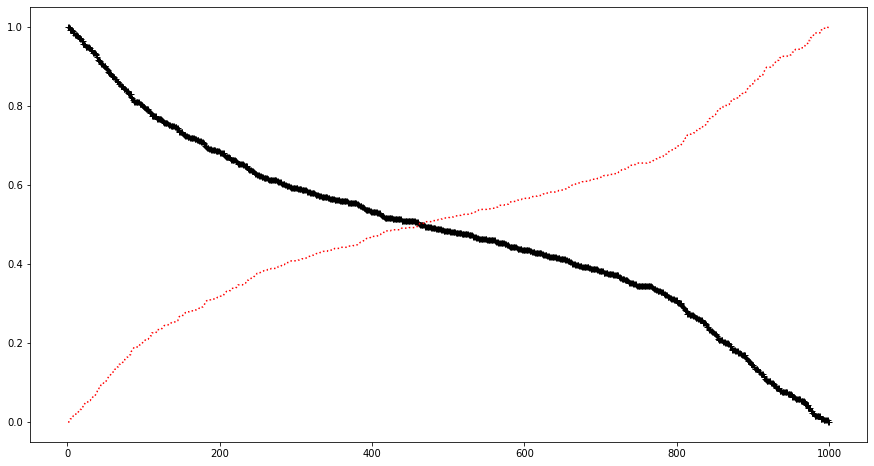

In [60]:
pre_test_prob=pd.DataFrame(LR.predict_proba(X_test))
from sklearn.metrics import confusion_matrix
tp_list = []
fn_list = []
for i in range(1000):
  pre_test=pre_test_prob[0].apply(lambda x: 0 if x*1000>i else 1)
  tp = confusion_matrix(pre_test,y_test)[0,0]
  fn = confusion_matrix(pre_test,y_test)[1,1]
  tp_precision = tp/(tp+fn)
  fn_precision = fn/(tp+fn)
  # print(tp_precision,fn_precision)
  if -0.001< (tp/(tp+fn))-(fn/(tp+fn)) <0.001:
    print(i/1000)
  else:
    pass
  tp_list.append(tp_precision)
  fn_list.append(fn_precision)
plt.plot([i for i in range(1,1001)], tp_list, 'k--+')   
plt.plot([i for i in range(1,1001)], fn_list, 'r:')

In [63]:
#以切割值調整精準度,p為切割值，取得預測結果
p = 0.461
pre_t=pre_test_prob[0].apply(lambda x: 0 if x>p else 1)

In [64]:
#計算正確率、精準度、召回率及綜合指標f1(train訓練集)
from sklearn.metrics import classification_report,confusion_matrix
print(metrics.classification_report(y_test,pre_t))

              precision    recall  f1-score   support

           0       0.75      0.76      0.75       244
           1       0.76      0.75      0.75       248

    accuracy                           0.75       492
   macro avg       0.75      0.75      0.75       492
weighted avg       0.75      0.75      0.75       492



使用切割值之後依然跟上兩個機器學習方法看起來沒有差很多

因測試與訓練集的精確度都只有0.7多且f1的準確度也是一樣0.7多

可看出此模型跟上面一樣